# Análise: dificuldade pelo GPT-5.4 e desempenho dos modelos Ollama

Este notebook cruza a classificação de dificuldade gerada pelo GPT-5.4 com as respostas dos modelos Ollama. A análise responde: como está a distribuição das questões, em que tópicos elas são mais difíceis e quais tipos de questão os modelos locais acertam mais.

A principal medida é **acurácia por classificação GPT-5.4** (fácil, média, difícil). As dimensões da rubrica - integração, raciocínio, demanda cognitiva, especificidade técnica e distratores - explicam quais características se associam aos acertos.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_colwidth', 140)
plt.style.use('seaborn-v0_8-whitegrid')


def find_root(start=Path.cwd()):
    for path in (start.resolve(), *start.resolve().parents):
        if (path / 'azure_openai_backend.py').exists():
            return path
    raise RuntimeError('Não encontrei a raiz do projeto.')


ROOT = find_root()
# Deixe como None para a procura automática. Se necessário, informe aqui o CSV ou JSONL Azure.
AZURE_RESULTS_PATH = None
OLLAMA_PATH = ROOT / 'pipeline' / 'fase_3' / 'analysis' / 'resultados_dificuldade' / 'respostas_ollama.jsonl'
# Lista oficial em pipeline/fase_3/analysis/avaliacao_dificuldade_ollama.ipynb.
SELECTED_OLLAMA_MODELS = ['gemma2:2b', 'phi4-mini:latest', 'qwen3:4b']
QUESTIONS_PATH = ROOT / 'pipeline' / 'fase_3' / 'saida_fase3' / 'questoes_fase3.jsonl'
OUT_DIR = ROOT / 'pipeline' / 'fase_4' / 'analise_dificuldade'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Ollama: {OLLAMA_PATH}')
print(f'Modelos considerados: {SELECTED_OLLAMA_MODELS}')
print(f'Questões: {QUESTIONS_PATH}')

Ollama: C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\MCQ_CONTEXT_GEN\pipeline\fase_3\analysis\resultados_dificuldade\respostas_ollama.jsonl
Modelos considerados: ['gemma2:2b', 'phi4-mini:latest', 'llama3.2:3b']
Questões: C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\MCQ_CONTEXT_GEN\pipeline\fase_3\saida_fase3\questoes_fase3.jsonl


In [2]:
DIMENSIONS = ['integracao_conhecimento', 'cadeia_raciocinio', 'demanda_cognitiva', 'especificidade_tecnica', 'plausibilidade_distratores']
DIFFICULTY_ORDER = ['facil', 'media', 'dificil']


def discover_azure_results():
    if AZURE_RESULTS_PATH is not None:
        path = Path(AZURE_RESULTS_PATH)
        if not path.is_file():
            raise FileNotFoundError(f'Arquivo Azure não encontrado: {path}')
        return path

    preferred = [
        ROOT / 'pipeline' / 'fase_4' / 'resultados_dificuldade_azure' / 'dificuldades_fase3.jsonl',
        ROOT / 'pipeline' / 'fase_4' / 'resultados_dificuldade_azure' / 'avaliacoes_checkpoint.jsonl',
        ROOT / 'pipeline' / 'fase_4' / 'resultados_dificuldade_azure' / 'dificuldades_fase3.csv',
    ]
    for path in preferred:
        if path.is_file():
            return path

    for path in ROOT.joinpath('pipeline', 'fase_4').rglob('*.csv'):
        try:
            if {'id', 'difficulty_score', 'difficulty_label'} <= set(pd.read_csv(path, nrows=1).columns):
                return path
        except Exception:
            pass
    raise FileNotFoundError(
        'Não encontrei o resultado Azure. Informe AZURE_RESULTS_PATH na célula anterior. '
        'O notebook de avaliação padrão salva em pipeline/fase_4/resultados_dificuldade_azure/.'
    )


def load_azure(path):
    if path.suffix.lower() == '.csv':
        data = pd.read_csv(path)
    else:
        rows = []
        for line in path.read_text(encoding='utf-8').splitlines():
            if line.strip():
                rows.append(json.loads(line))
        data = pd.DataFrame(rows)
        if 'status' in data.columns:
            data = data[data['status'].eq('ok')]
        data = data.drop_duplicates('id', keep='last')
    required = {'id', 'difficulty_score', 'difficulty_label'}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f'O arquivo Azure não tem os campos esperados: {sorted(missing)}')
    data['difficulty_label'] = (data['difficulty_label'].astype(str).str.lower()
        .str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('ascii'))
    return data.drop_duplicates('id', keep='last')


azure_path = discover_azure_results()
azure = load_azure(azure_path)
print(f'Azure: {azure_path} | {len(azure):,} avaliações válidas')
azure[['id', 'difficulty_score', 'difficulty_label'] + [d for d in DIMENSIONS if d in azure.columns]].head()

Azure: C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\MCQ_CONTEXT_GEN\pipeline\fase_4\resultados_dificuldade_azure\dificuldades_fase3.jsonl | 15,828 avaliações válidas


,id,difficulty_score,difficulty_label,integracao_conhecimento,cadeia_raciocinio,demanda_cognitiva,especificidade_tecnica,plausibilidade_distratores
0,00b1e9d74a-f0-d0-r1-q0,3.0,dificil,3,3,3,3,3
1,00b1e9d74a-f0-d0-r1-q3,3.0,dificil,3,3,3,3,3
2,00b1e9d74a-f0-d0-r2-q1,3.0,dificil,3,3,3,3,3
3,00b1e9d74a-f0-d0-r4-q1,3.0,dificil,3,3,3,3,3
4,00b1e9d74a-f0-d0-r4-q2,3.0,dificil,3,3,3,3,3


In [3]:
def load_jsonl(path):
    if not path.is_file():
        raise FileNotFoundError(path)
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]


# O JSONL guarda também respostas de execuções antigas; filtra-se a lista
# oficial definida na célula de configuração.
ollama = pd.DataFrame(load_jsonl(OLLAMA_PATH))
ollama = ollama[ollama['model'].isin(SELECTED_OLLAMA_MODELS) & ollama['correct'].notna()]
ollama = ollama.drop_duplicates(['id', 'model'], keep='last')
metadata = pd.DataFrame(load_jsonl(QUESTIONS_PATH))
metadata = metadata[['id', 'topico', 'subtopico', 'difficulty', 'nota']].drop_duplicates('id', keep='last')

questions = azure.merge(metadata, on='id', how='left', suffixes=('', '_fase3'))
answers = ollama.merge(questions, on='id', how='inner')

print(f'Respostas Ollama: {len(ollama):,} ({ollama["model"].nunique()} modelos)')
print(f'Questões Azure com metadados da Fase 3: {questions["topico"].notna().sum():,}/{len(questions):,}')
print(f'Pares modelo-questão no cruzamento: {len(answers):,}; questões cobertas: {answers["id"].nunique():,}')

coverage = (answers[['id']].drop_duplicates().merge(questions[['id', 'difficulty_label']], on='id', how='right')
    .assign(coberta=lambda x: x['difficulty_label'].notna() & x['id'].isin(answers['id'])))
display(coverage.groupby('difficulty_label')['coberta'].agg(questoes='size', cobertas='sum', cobertura_pct='mean').assign(cobertura_pct=lambda x: x['cobertura_pct'].mul(100).round(1)))

Respostas Ollama: 47,499 (3 modelos)
Questões Azure com metadados da Fase 3: 15,828/15,828
Pares modelo-questão no cruzamento: 47,484; questões cobertas: 15,828


,questoes,cobertas,cobertura_pct
difficulty_label,,,
dificil,8913,8913,100.0
facil,240,240,100.0
media,6675,6675,100.0


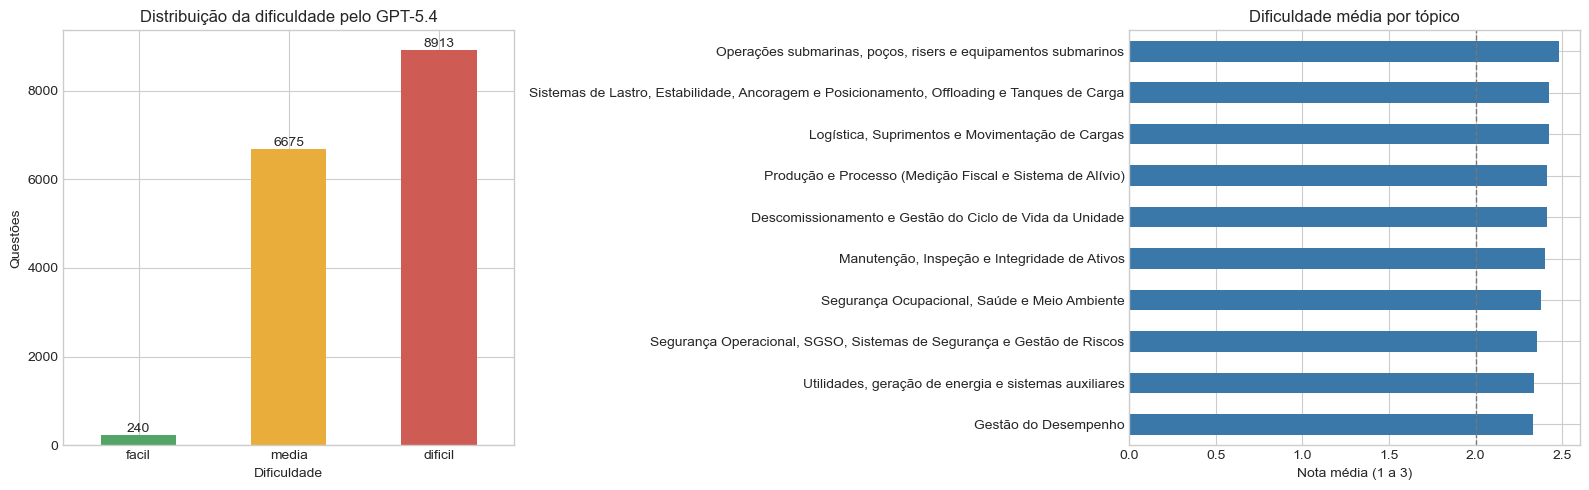

,dificuldade_media,questoes
topico,,
"Operações submarinas, poços, risers e equipamentos submarinos",2.48,740
"Logística, Suprimentos e Movimentação de Cargas",2.43,461
"Sistemas de Lastro, Estabilidade, Ancoragem e Posicionamento, Offloading e Tanques de Carga",2.43,1136
Produção e Processo (Medição Fiscal e Sistema de Alívio),2.42,7050
Descomissionamento e Gestão do Ciclo de Vida da Unidade,2.41,350
"Manutenção, Inspeção e Integridade de Ativos",2.40,1418
"Segurança Ocupacional, Saúde e Meio Ambiente",2.38,1354
"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",2.35,1954
"Utilidades, geração de energia e sistemas auxiliares",2.34,853


In [4]:
# Como estão as questões: distribuição e dificuldade média por tópico.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts = questions['difficulty_label'].value_counts().reindex(DIFFICULTY_ORDER, fill_value=0)
counts.plot.bar(ax=axes[0], color=['#53a567', '#e9ad3c', '#ce5b54'], rot=0)
axes[0].set(title='Distribuição da dificuldade pelo GPT-5.4', xlabel='Dificuldade', ylabel='Questões')
for bar, value in zip(axes[0].patches, counts):
    axes[0].annotate(str(value), (bar.get_x() + bar.get_width() / 2, value), ha='center', va='bottom')

topic_score = questions.dropna(subset=['topico']).groupby('topico')['difficulty_score'].agg(['mean', 'size']).sort_values('mean')
topic_score['mean'].plot.barh(ax=axes[1], color='#3978a8')
axes[1].set(title='Dificuldade média por tópico', xlabel='Nota média (1 a 3)', ylabel='')
axes[1].axvline(2, color='#777777', lw=1, ls='--')
plt.tight_layout()
plt.show()

display(topic_score.rename(columns={'mean': 'dificuldade_media', 'size': 'questoes'}).round(2).sort_values('dificuldade_media', ascending=False))

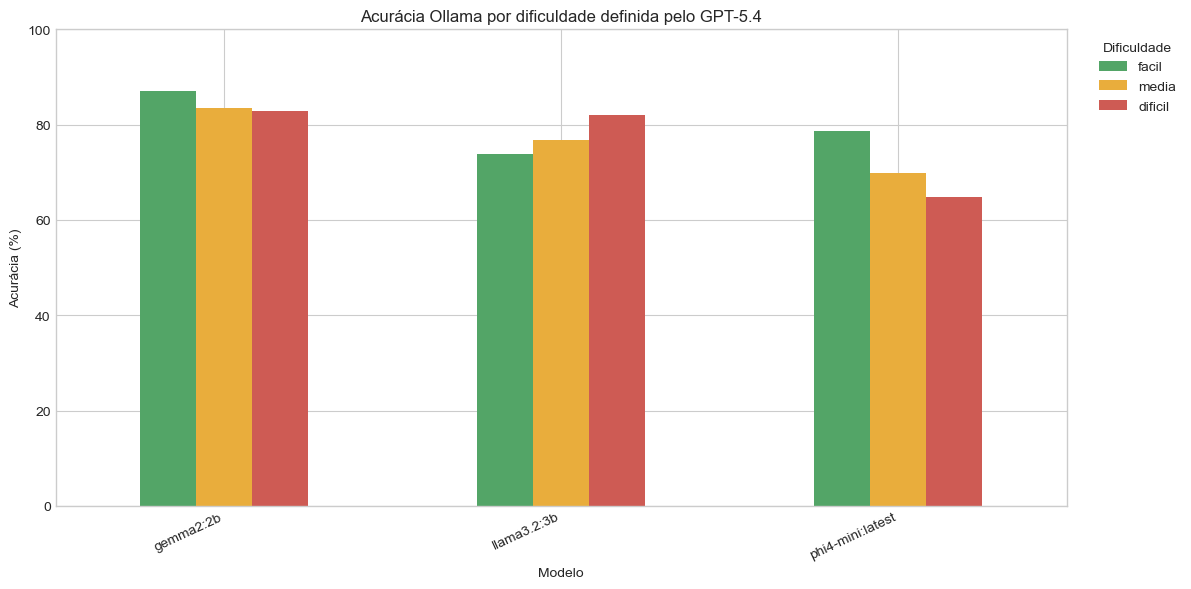

,acuracia,respostas
model,,
gemma2:2b,83.2,15828
llama3.2:3b,79.6,15828
phi4-mini:latest,67.1,15828


,model,difficulty_label,acuracia,respostas
0,gemma2:2b,dificil,82.9,8913
1,gemma2:2b,facil,87.1,240
2,gemma2:2b,media,83.4,6675
3,llama3.2:3b,dificil,81.9,8913
4,llama3.2:3b,facil,73.8,240
5,llama3.2:3b,media,76.8,6675
6,phi4-mini:latest,dificil,64.8,8913
7,phi4-mini:latest,facil,78.8,240
8,phi4-mini:latest,media,69.8,6675


In [5]:
# Principal: em quais níveis de dificuldade cada modelo Ollama acerta mais.
accuracy = (answers.groupby(['model', 'difficulty_label'])['correct'].agg(acuracia='mean', respostas='size')
    .reset_index())
pivot = accuracy.pivot(index='model', columns='difficulty_label', values='acuracia').reindex(columns=DIFFICULTY_ORDER)

ax = pivot.mul(100).plot(kind='bar', figsize=(12, 6), color=['#53a567', '#e9ad3c', '#ce5b54'])
ax.set(title='Acurácia Ollama por dificuldade definida pelo GPT-5.4', xlabel='Modelo', ylabel='Acurácia (%)')
ax.set_ylim(0, 100)
ax.legend(title='Dificuldade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

overall = answers.groupby('model')['correct'].agg(acuracia='mean', respostas='size').sort_values('acuracia', ascending=False)
display(overall.assign(acuracia=lambda x: x['acuracia'].mul(100).round(1)))
display(accuracy.assign(acuracia=lambda x: x['acuracia'].mul(100).round(1)).sort_values(['model', 'difficulty_label']))

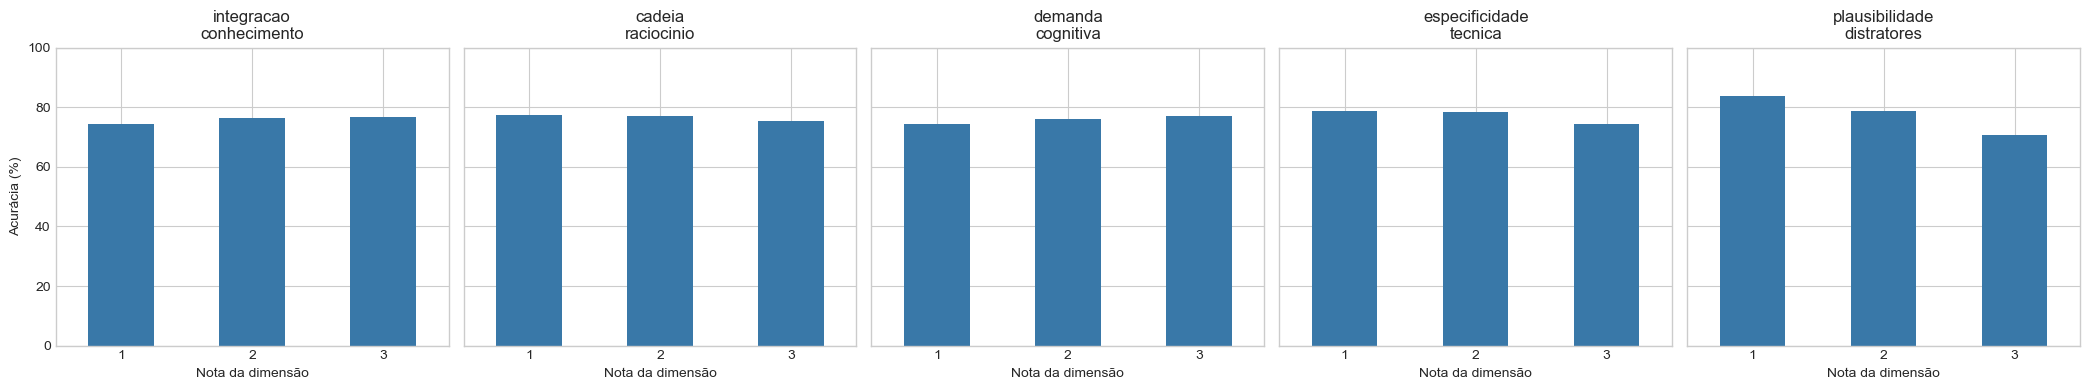

,acuracia,respostas
topico,,
Gestão do Desempenho,83.9,1536
"Segurança Operacional, SGSO, Sistemas de Segurança e Gestão de Riscos",80.6,5862
Descomissionamento e Gestão do Ciclo de Vida da Unidade,80.6,1050
"Manutenção, Inspeção e Integridade de Ativos",80.2,4254
"Segurança Ocupacional, Saúde e Meio Ambiente",79.9,4062
"Logística, Suprimentos e Movimentação de Cargas",77.5,1383
Produção e Processo (Medição Fiscal e Sistema de Alívio),75.2,21150
"Operações submarinas, poços, risers e equipamentos submarinos",74.4,2220
"Sistemas de Lastro, Estabilidade, Ancoragem e Posicionamento, Offloading e Tanques de Carga",71.8,3408


Resumo exportado: C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\MCQ_CONTEXT_GEN\pipeline\fase_4\analise_dificuldade\acuracia_ollama_por_dificuldade.csv


In [6]:
# Quais características da rubrica estão associadas a mais acertos?
available_dimensions = [d for d in DIMENSIONS if d in answers.columns]
if not available_dimensions:
    print('O resultado Azure não contém as dimensões da rubrica; esta análise não está disponível.')
else:
    fig, axes = plt.subplots(1, len(available_dimensions), figsize=(4.2 * len(available_dimensions), 4), sharey=True)
    axes = [axes] if len(available_dimensions) == 1 else axes
    for axis, dimension in zip(axes, available_dimensions):
        values = answers.groupby(dimension)['correct'].agg(['mean', 'size']).reindex([1, 2, 3])
        values['mean'].mul(100).plot.bar(ax=axis, color='#3978a8', rot=0)
        axis.set(title=dimension.replace('_', '\n'), xlabel='Nota da dimensão', ylabel='Acurácia (%)')
        axis.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

    topic_accuracy = (answers.groupby('topico')['correct'].agg(acuracia='mean', respostas='size')
        .sort_values('acuracia', ascending=False).assign(acuracia=lambda x: x['acuracia'].mul(100).round(1)))
    display(topic_accuracy)

    summary_path = OUT_DIR / 'acuracia_ollama_por_dificuldade.csv'
    accuracy.to_csv(summary_path, index=False, encoding='utf-8-sig')
    print(f'Resumo exportado: {summary_path}')